In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Read the data

###### Classification Data

In [2]:
cdata = pd.read_csv('../../datasets/pima_indians_diabetes.csv')
cdata.head(3)

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [4]:
cx = cdata.iloc[:,:8]
cy = cdata.iloc[:,8]

###### Regression Data

In [3]:
rdata = pd.read_csv('../../datasets/boston.csv')
rdata.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


In [7]:
rx = rdata.iloc[:,:13]
ry = rdata.iloc[:,13]

#### 1. Univariate Selection

##### Classification

In [10]:
from sklearn.feature_selection import SelectKBest, chi2, f_regression

In [18]:
cmodel = SelectKBest(k=4,score_func=chi2)
selected_data = cmodel.fit_transform(cx,cy)
selected_data

array([[148. ,   0. ,  33.6,  50. ],
       [ 85. ,   0. ,  26.6,  31. ],
       [183. ,   0. ,  23.3,  32. ],
       ...,
       [121. , 112. ,  26.2,  30. ],
       [126. ,   0. ,  30.1,  47. ],
       [ 93. ,   0. ,  30.4,  23. ]])

In [15]:
filt = cmodel.get_support()
filt

array([False,  True, False, False,  True,  True, False,  True])

In [13]:
cx.columns

Index(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'], dtype='object')

In [17]:
selected_features = cx.columns[filt]
selected_features

Index(['plas', 'test', 'mass', 'age'], dtype='object')

In [20]:
model_data = pd.DataFrame(selected_data, columns=selected_features)
model_data['class'] = cdata['class']
model_data.head()

,plas,test,mass,age,class
0,148.0,0.0,33.6,50.0,1
1,85.0,0.0,26.6,31.0,0
2,183.0,0.0,23.3,32.0,1
3,89.0,94.0,28.1,21.0,0
4,137.0,168.0,43.1,33.0,1


In [21]:
cmodel.scores_

array([ 111.51969064, 1411.88704064,   17.60537322,   53.10803984,
       2175.56527292,  127.66934333,    5.39268155,  181.30368904])

In [22]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = cx.columns
feat_imp['importance'] = cmodel.scores_
feat_imp

,feature,importance
0,preg,111.519691
1,plas,1411.887041
2,pres,17.605373
3,skin,53.108040
4,test,2175.565273
5,mass,127.669343
6,pedi,5.392682
7,age,181.303689


In [23]:
feat_imp.sort_values(by='importance', ascending=False)

,feature,importance
4,test,2175.565273
1,plas,1411.887041
7,age,181.303689
5,mass,127.669343
0,preg,111.519691
3,skin,53.108040
2,pres,17.605373
6,pedi,5.392682


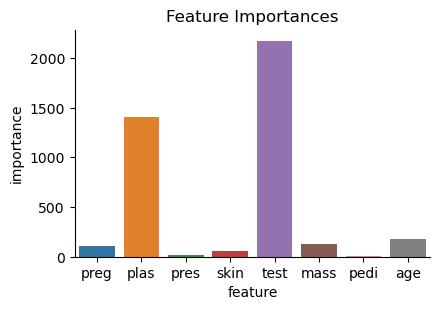

In [25]:
sns.catplot(feat_imp, x='feature', y='importance',
            kind='bar',
            height=3,
            aspect=1.5,
            hue='feature'
           )
plt.title('Feature Importances')
plt.show()

#### Regression

In [28]:
rmodel = SelectKBest(k=8, score_func=f_regression)
selected_data = rmodel.fit_transform(rx,ry)

In [27]:
filt = rmodel.get_support()
selected_features = rx.columns[filt]
selected_features

Index(['CRIM', 'INDUS', 'NOX', 'RM', 'RAD', 'TAX', 'PTRATIO', 'LSTAT'], dtype='object')

In [30]:
rmodel_data = pd.DataFrame(selected_data, columns=selected_features)
rmodel_data['HousePrice'] = rdata['House Price']
rmodel_data.head()

,CRIM,INDUS,NOX,RM,RAD,TAX,PTRATIO,LSTAT,HousePrice
0,0.00632,2.31,0.538,6.575,1.0,296.0,15.3,4.98,24.0
1,0.02731,7.07,0.469,6.421,2.0,242.0,17.8,9.14,21.6
2,0.02729,7.07,0.469,7.185,2.0,242.0,17.8,4.03,34.7
3,0.03237,2.18,0.458,6.998,3.0,222.0,18.7,2.94,33.4
4,0.06905,2.18,0.458,7.147,3.0,222.0,18.7,5.33,36.2


In [31]:
rmodel.scores_

array([ 89.48611476,  75.2576423 , 153.95488314,  15.97151242,
       112.59148028, 471.84673988,  83.47745922,  33.57957033,
        85.91427767, 141.76135658, 175.10554288,  63.05422911,
       601.61787111])

In [32]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = rx.columns
feat_imp['importance'] = rmodel.scores_
feat_imp

,feature,importance
0,CRIM,89.486115
1,ZN,75.257642
2,INDUS,153.954883
3,CHAS,15.971512
4,NOX,112.591480
5,RM,471.846740
6,AGE,83.477459
7,DIS,33.579570
8,RAD,85.914278
9,TAX,141.761357


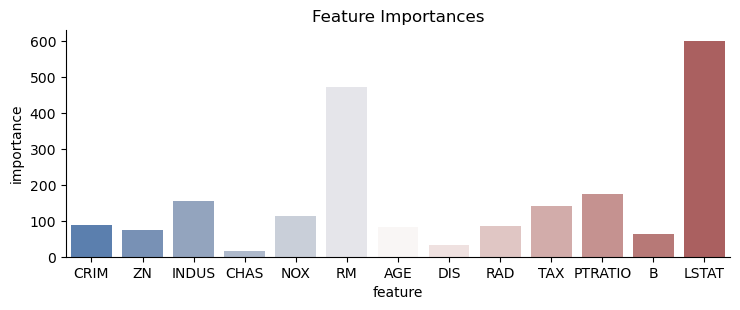

In [36]:
sns.catplot(feat_imp, x='feature', y='importance',
            kind='bar',
            height=3,
            aspect=2.5,
            hue='feature',
            palette='vlag'
           )
plt.title('Feature Importances')
plt.show()

##### 2. Recursive Feature Selection

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [38]:
rf_model = RFE(estimator=LogisticRegression(max_iter=400), n_features_to_select=4 )
rf_model.fit_transform(cx,cy)

array([[  6.   , 148.   ,  33.6  ,   0.627],
       [  1.   ,  85.   ,  26.6  ,   0.351],
       [  8.   , 183.   ,  23.3  ,   0.672],
       ...,
       [  5.   , 121.   ,  26.2  ,   0.245],
       [  1.   , 126.   ,  30.1  ,   0.349],
       [  1.   ,  93.   ,  30.4  ,   0.315]])

In [39]:
rf_model.ranking_

array([1, 1, 3, 5, 4, 1, 1, 2])

In [41]:
feat_rank = pd.DataFrame()
feat_rank['feature'] = cx.columns
feat_rank['rank'] = rf_model.ranking_
feat_rank

,feature,rank
0,preg,1
1,plas,1
2,pres,3
3,skin,5
4,test,4
5,mass,1
6,pedi,1
7,age,2


In [42]:
feat_rank.sort_values(by='rank')

,feature,rank
0,preg,1
1,plas,1
5,mass,1
6,pedi,1
7,age,2
2,pres,3
4,test,4
3,skin,5


#### Regression

ToDo : Complete this

##### 3. Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
ctree =  DecisionTreeClassifier(max_depth=6)
ctree.fit(cx,cy)

DecisionTreeClassifier(max_depth=6)

In [45]:
ctree.feature_importances_

array([0.02425246, 0.42382495, 0.06735106, 0.00526877, 0.02853439,
       0.23015291, 0.09535546, 0.12526   ])

In [46]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = cx.columns
feat_imp['importance'] = ctree.feature_importances_
feat_imp

,feature,importance
0,preg,0.024252
1,plas,0.423825
2,pres,0.067351
3,skin,0.005269
4,test,0.028534
5,mass,0.230153
6,pedi,0.095355
7,age,0.125260


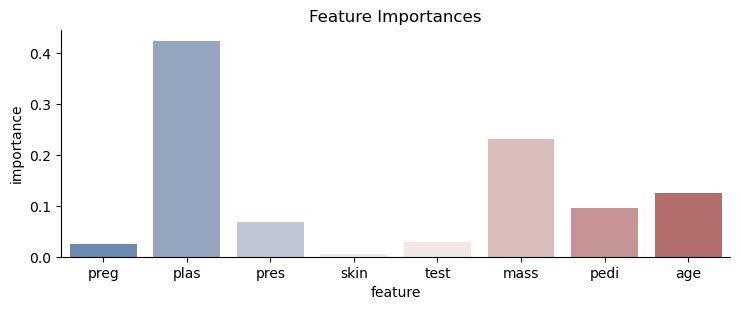

In [47]:
sns.catplot(feat_imp, x='feature', y='importance',
            kind='bar',
            height=3,
            aspect=2.5,
            hue='feature',
            palette='vlag'
           )
plt.title('Feature Importances')
plt.show()

##### Regression

In [48]:
from sklearn.tree import DecisionTreeRegressor

In [49]:
rtree = DecisionTreeRegressor(max_depth=8)
rtree.fit(rx,ry)

DecisionTreeRegressor(max_depth=8)

In [50]:
rtree.feature_importances_

array([4.65715611e-02, 5.18042541e-04, 3.06953583e-03, 2.49568912e-04,
       4.90756004e-02, 5.84197881e-01, 1.05299678e-02, 7.31450896e-02,
       1.33615789e-02, 1.12559062e-02, 6.06724044e-03, 3.70513922e-03,
       1.98252888e-01])

In [51]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = rx.columns
feat_imp['importance'] = rtree.feature_importances_
feat_imp

,feature,importance
0,CRIM,0.046572
1,ZN,0.000518
2,INDUS,0.003070
3,CHAS,0.000250
4,NOX,0.049076
5,RM,0.584198
6,AGE,0.010530
7,DIS,0.073145
8,RAD,0.013362
9,TAX,0.011256


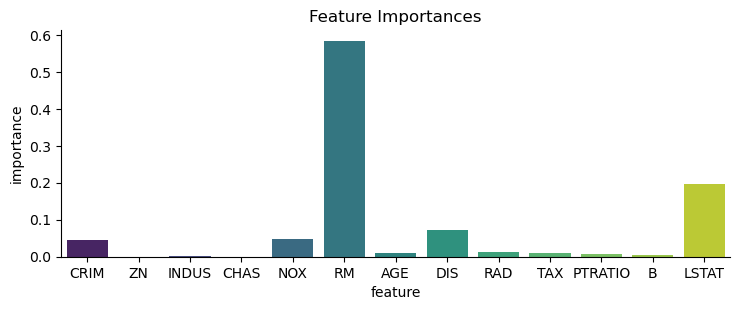

In [52]:
sns.catplot(feat_imp, x='feature', y='importance',
            kind='bar',
            height=3,
            aspect=2.5,
            hue='feature',
            palette='viridis'
           )
plt.title('Feature Importances')
plt.show()